In [1]:
import numpy as np
import scipy.integrate
import scipy as sp
import matplotlib.pyplot as plt
from numpy import sqrt
from numpy.linalg import norm
import scipy.io as scio
from scipy import interpolate
import scipy.special as special
import math
from numpy import tanh, cosh, sqrt, cos, sin, exp, log, pi
from scipy.integrate import quad, quad_vec
from scipy.optimize import fsolve, bisect, dual_annealing

In [2]:
# Chose between rademacher or gaussian theory

#opt = 'rad'
opt = 'gauss'

In [ ]:
import numpy as np
from numpy.polynomial.hermite import hermgauss
from scipy.optimize import brentq

# --- Gauss-Hermite setup (choose order; 40 is usually very accurate) ---
_GH_ORDER = 40
_GH_x, _GH_w = hermgauss(_GH_ORDER)               # nodes x_i, weights w_i for e^{-x^2}
_GH_scale = 1.0/np.sqrt(np.pi)                    # factor described below

# For standard normal integrals: 
# ∫ f(z) φ(z) dz ≈ (1/√π) * Σ_i w_i * f(√2 * x_i)

def _gauss_hermite_expectation(f_vals_at_scaled_nodes):
    # weights scaled by 1/√π
    return np.tensordot(_GH_w * _GH_scale, f_vals_at_scaled_nodes, axes=(0,0))


def psi_w_vec(l_arr, opt='rad'):
    l = np.asarray(l_arr, dtype=float)
    if opt == 'gauss':
        # psi_w(l) = l/(1+l), can broadcast
        return l / (1.0 + l)

    # opt == 'rad' -> integral: E_z[ tanh(sqrt(l) * z + l) ] where z ~ N(0,1)
    scalar_input = (l.ndim == 0)
    l = l.ravel() if not scalar_input else l.reshape(1)
    # compute scaled nodes: z_i = sqrt(2) * x_i, shape (N,)
    z_nodes = np.sqrt(2.0) * _GH_x                       # shape (N,)
    # we need sqrt(l) * z + l for each l and each z -> produce shape (N, L)
    # do it with broadcasting: z_nodes[:,None] * sqrt_l[None,:] + l[None,:]
    sqrt_l = np.sqrt(np.maximum(l, 0.0))                 # shape (L,)
    arg = z_nodes[:, None] * sqrt_l[None, :] + l[None, :]  # (N, L)
    vals = np.tanh(arg)                                  # (N, L)
    exps = _gauss_hermite_expectation(vals)              # shape (L,)
    return exps.reshape(()) if scalar_input else exps


def psi_vec(g_arr, opt='rad'):
    g = np.asarray(g_arr, dtype=float)
    if opt == 'gauss':
        return 0.5 * g - 0.5 * np.log(1.0 + g)

    # rad case: psi(g) = -g/2 + E_z[ log cosh( sqrt(g)*z + g ) ]
    scalar_input = (g.ndim == 0)
    g = g.ravel() if not scalar_input else g.reshape(1)
    z_nodes = np.sqrt(2.0) * _GH_x                         # shape (N,)
    sqrt_g = np.sqrt(np.maximum(g, 0.0))                   # shape (L,)
    arg = z_nodes[:, None] * sqrt_g[None, :] + g[None, :]  # (N, L)
    vals = np.log(np.cosh(arg))                            # (N, L)
    exps = _gauss_hermite_expectation(vals)                # (L,)
    out = -0.5 * g + exps
    return out.reshape(()) if scalar_input else out


def m_inv_vec(q, opt='rad'):
    q_arr = np.atleast_1d(q).astype(float)
    out = np.empty_like(q_arr)

    if opt == 'gauss':
        out = q_arr / (1.0 - q_arr)
        return out if q_arr.shape != () else out.item()

    # rad: do bracket search by doubling until psi_w(u) >= q
    for idx, qv in enumerate(q_arr):
        if qv <= 0:
            out[idx] = 0.0
            continue
        # find u such that psi_w(u) >= qv
        lo = 0.0
        hi = 1.0
        while psi_w_vec(hi, opt=opt) < qv:
            hi *= 2.0
            if hi > 1e6:
                # give up and set large value
                break
        # now root-find on [lo, hi] for f(l) = psi_w(l) - qv
        f = lambda x: psi_w_vec(x, opt=opt) - qv
        # brentq needs scalar callable; psi_w_vec is fast because GH quadrature is vectorized
        root = brentq(f, lo, hi, maxiter=100, xtol=1e-12)
        out[idx] = root

    return out if q_arr.shape != () else out.item()


def EE_s(arr, P_v):
    P_v = np.asarray(P_v)
    return np.tensordot(P_v, arr, axes=(0, 0))


def EE_s_g(q_W, v, P_v, g):
    q_W = np.asarray(q_W)
    v = np.asarray(v)
    P_v = np.asarray(P_v)
    return np.dot(P_v, (v**2) * g(q_W))


def EE_s_qW2(q_W, v, P_v):
    q_W = np.asarray(q_W)
    v = np.asarray(v)
    P_v = np.asarray(P_v)
    return np.dot(P_v, (v**2) * (q_W**2))


def EE_FSB(mat, arr, P_v):
    # ensure numpy arrays
    mat = np.asarray(mat)
    arr = np.asarray(arr)
    P_v = np.asarray(P_v)
    return mat.dot(P_v * arr)

def mmse_qW_NSB_FSB_fast(
    q_W_1_init, q_W_2_init, q_W_12_init,
    g_1, g_1_prime, g_3, g_3_prime,
    v, P_v, s2, P_s2,
    d, coeff, alpha, gamma_1, gamma_2, delta,
    max_iter=1000, tol=1e-8, damp=0.1,
    opt='gauss'
):
    # copy inputs to avoid mutating user data
    q_W_1 = q_W_1_init.copy()        # (S,)
    q_W_2 = q_W_2_init.copy()        # (V,S)
    q_W_12 = q_W_12_init.copy()      # (V,)
    V = v.shape[0]
    S = s2.shape[0]

    # Local references for speed
    g3 = g_3
    g3p = g_3_prime
    EE_FSB_local = EE_FSB
    EE_s_g_local = EE_s_g
    EE_s_local = EE_s

    c1 = coeff[1]**2
    c1_4 = coeff[1]**4
    alpha_over_gamma1 = alpha / gamma_1
    alpha_over_gamma2 = alpha / gamma_2
    alpha_over_gamma1_gamma2 = alpha / (gamma_1 * gamma_2)
    gamma2_over_gamma1 = gamma_2 / gamma_1
    inv_gamma1 = 1.0 / gamma_1

    # Precompute commonly used 1D vector
    Pv_v2 = P_v * (v**2)   # shape (V,)

    # initial r_K and q_K
    r_K = g_1(g_1(1.0))
    q_K = (
        c1_4
        + c1 * EE_s_g_local(q_W_1, s2, P_s2, g3)
        + EE_s_g_local(c1 * q_W_12 + EE_FSB_local(q_W_2, g3(q_W_1), P_s2), v, P_v, g3)
    )

    # Preallocate buffers reused every iteration
    r_W_1 = np.empty(S, dtype=q_W_1.dtype)
    r_W_2 = np.empty((V, S), dtype=q_W_2.dtype)
    # temporary buffer for outer-product second term (we'll reuse it)
    tmp_outer = np.empty((V, S), dtype=q_W_2.dtype)

    # For faster attribute access in loop
    dot = np.dot
    multiply = np.multiply

    # Prepare psi function depending on opt
    if opt == 'gauss':
        # fast vectorized closed-form psi for gaussian prior
        def psi_w_arr(r):
            r = np.asarray(r)
            return r / (1.0 + r)
    else:
        # fallback: apply existing scalar psi_w elementwise (preserves behavior for 'rad' etc.)
        psi_scalar_vec = np.vectorize(psi_w)
        def psi_w_arr(r):
            # ensure input as array, apply vectorized scalar psi, then reshape to same shape
            r = np.asarray(r)
            out = psi_scalar_vec(r.ravel())
            return out.reshape(r.shape)

    for it in range(max_iter):
        denom = (delta + r_K - q_K)  # scalar

        # Precompute repeated arrays
        g3_qW1 = g3(q_W_1)                     # (S,)
        EE_FSB_val = EE_FSB_local(q_W_2, g3_qW1, P_s2)   # (V,)
        inner = c1 * q_W_12 + EE_FSB_val       # (V,)
        g3p_inner = g3p(inner)                 # (V,)
        # v^2 * g3p_inner
        v2_g3p_inner = (v**2) * g3p_inner      # (V,)

        # r_W_12 (V,)
        r_W_12 = (alpha_over_gamma2 * c1 * v2_g3p_inner) / denom

        # EE_FSB(q_W_2, q_W_1, P_s2) (V,)
        EE_FSB_qW2_qW1 = EE_FSB_local(q_W_2, q_W_1, P_s2)
        one_minus_EE = 1.0 - EE_FSB_qW2_qW1
        denom2 = 1.0 + r_W_12 * one_minus_EE   # (V,)

        # ---------- r_W_1 (S,) ----------
        # termA:
        termA = (alpha_over_gamma1 * c1 / denom) * (s2**2) * g3p(q_W_1)

        # termB: compute Pv_weight_for_B = Pv_v2 * g3p_inner (V,)
        Pv_weight_for_B = Pv_v2 * g3p_inner   # (V,)
        # S_vec = Pv_weight_for_B dot q_W_2  -> shape (S,)
        S_vec = dot(Pv_weight_for_B, q_W_2)   # (S,)
        termB = (alpha_over_gamma2 / denom) * (g3p(q_W_1) * S_vec)  # (S,)

        # termC: weight_R = P_v * r_W_12 / denom2  -> (V,)
        weight_R = P_v * (r_W_12 / denom2)    # (V,)
        C_vec = dot(weight_R, q_W_2)          # (S,)
        termC = gamma2_over_gamma1 * C_vec    # (S,)

        # r_W_1
        r_W_1 = termA + termB + termC

        # ---------- r_W_2 (V,S) ----------
        pref1 = alpha_over_gamma1_gamma2 / denom

        # compute term1 in-place into r_W_2 using broadcasting with out:
        multiply(v2_g3p_inner[:, None], g3_qW1[None, :], out=r_W_2)  # r_W_2 = outer(v2_g3p_inner, g3_qW1)
        # scale
        r_W_2 *= pref1

        # compute second term into tmp_outer (reuse tmp_outer)
        multiply((r_W_12 / denom2)[:, None], q_W_1[None, :], out=tmp_outer)  # tmp_outer = outer(r_W_12/denom2, q_W_1)
        # scale and add to r_W_2
        r_W_2 += inv_gamma1 * tmp_outer

        # ---------- Update q_W_1, q_W_2, q_W_12 ----------
        # compute psi elementwise using selected opt
        q_W_1_new = psi_w_arr(r_W_1)    # (S,)
        q_W_1 = (1.0 - damp) * q_W_1 + damp * q_W_1_new

        q_W_2_new = psi_w_arr(r_W_2)    # (V,S)
        q_W_2 = (1.0 - damp) * q_W_2 + damp * q_W_2_new

        # q_W_12 update (need EE_FSB(q_W_2, q_W_1, P_s2) recomputed with updated q_W_2 & q_W_1)
        one_minus_EE = 1.0 - EE_FSB_local(q_W_2, q_W_1, P_s2)  # (V,)
        q_W_12_new = 1.0 - one_minus_EE / (1.0 + r_W_12 * one_minus_EE)
        q_W_12 = (1.0 - damp) * q_W_12 + damp * q_W_12_new

        # ---------- Update q_K ----------
        q_K_new = (
            c1_4
            + c1 * EE_s_g_local(q_W_1, s2, P_s2, g3)
            + EE_s_g_local(c1 * q_W_12 + EE_FSB_local(q_W_2, g3_qW1, P_s2), v, P_v, g3)
        )

        # convergence
        if np.abs(q_K_new - q_K) < tol:
            q_K = q_K_new
            break

        q_K = q_K_new

    mmse = r_K - q_K
    return mmse, q_W_1, q_W_2, q_W_12

def free_entropy_NSB_FSB(
    q_W_1_init, q_W_2_init, q_W_12_init,
    g_1, g_1_prime, g_3, g_3_prime,
    v, P_v, s2, P_s2,
    d, coeff, alpha, gamma_1, gamma_2, delta,
    max_iter=1000, tol=1e-8, damp=0.1,
    opt='gauss'
):
    # copy inputs to avoid mutating user data
    q_W_1 = q_W_1_init.copy()        # (S,)
    q_W_2 = q_W_2_init.copy()        # (V,S)
    q_W_12 = q_W_12_init.copy()      # (V,)
    V = v.shape[0]
    S = s2.shape[0]

    # Local references for speed
    g3 = g_3
    g3p = g_3_prime
    EE_FSB_local = EE_FSB
    EE_s_g_local = EE_s_g
    EE_s_local = EE_s

    c1 = coeff[1]**2
    c1_4 = coeff[1]**4
    alpha_over_gamma1 = alpha / gamma_1
    alpha_over_gamma2 = alpha / gamma_2
    alpha_over_gamma1_gamma2 = alpha / (gamma_1 * gamma_2)
    gamma2_over_gamma1 = gamma_2 / gamma_1
    inv_gamma1 = 1.0 / gamma_1

    # Precompute commonly used 1D vector
    Pv_v2 = P_v * (v**2)   # shape (V,)

    # initial r_K and q_K
    r_K = g_1(g_1(1.0))
    q_K = (
        c1_4
        + c1 * EE_s_g_local(q_W_1, s2, P_s2, g3)
        + EE_s_g_local(c1 * q_W_12 + EE_FSB_local(q_W_2, g3(q_W_1), P_s2), v, P_v, g3)
    )

    # Preallocate buffers reused every iteration
    r_W_1 = np.empty(S, dtype=q_W_1.dtype)
    r_W_2 = np.empty((V, S), dtype=q_W_2.dtype)
    # temporary buffer for outer-product second term (we'll reuse it)
    tmp_outer = np.empty((V, S), dtype=q_W_2.dtype)

    # For faster attribute access in loop
    dot = np.dot
    multiply = np.multiply

    # Prepare psi function depending on opt
    if opt == 'gauss':
        # fast vectorized closed-form psi for gaussian prior
        def psi_w_arr(r):
            r = np.asarray(r)
            return r / (1.0 + r)
    else:
        # fallback: apply existing scalar psi_w elementwise (preserves behavior for 'rad' etc.)
        psi_scalar_vec = np.vectorize(psi_w)
        def psi_w_arr(r):
            # ensure input as array, apply vectorized scalar psi, then reshape to same shape
            r = np.asarray(r)
            out = psi_scalar_vec(r.ravel())
            return out.reshape(r.shape)

    for it in range(2):
        denom = (delta + r_K - q_K)  # scalar

        # Precompute repeated arrays
        g3_qW1 = g3(q_W_1)                     # (S,)
        EE_FSB_val = EE_FSB_local(q_W_2, g3_qW1, P_s2)   # (V,)
        inner = c1 * q_W_12 + EE_FSB_val       # (V,)
        g3p_inner = g3p(inner)                 # (V,)
        # v^2 * g3p_inner
        v2_g3p_inner = (v**2) * g3p_inner      # (V,)

        # r_W_12 (V,)
        r_W_12 = (alpha_over_gamma2 * c1 * v2_g3p_inner) / denom

        # EE_FSB(q_W_2, q_W_1, P_s2) (V,)
        EE_FSB_qW2_qW1 = EE_FSB_local(q_W_2, q_W_1, P_s2)
        one_minus_EE = 1.0 - EE_FSB_qW2_qW1
        denom2 = 1.0 + r_W_12 * one_minus_EE   # (V,)

        # ---------- r_W_1 (S,) ----------
        # termA:
        termA = (alpha_over_gamma1 * c1 / denom) * (s2**2) * g3p(q_W_1)

        # termB: compute Pv_weight_for_B = Pv_v2 * g3p_inner (V,)
        Pv_weight_for_B = Pv_v2 * g3p_inner   # (V,)
        # S_vec = Pv_weight_for_B dot q_W_2  -> shape (S,)
        S_vec = dot(Pv_weight_for_B, q_W_2)   # (S,)
        termB = (alpha_over_gamma2 / denom) * (g3p(q_W_1) * S_vec)  # (S,)

        # termC: weight_R = P_v * r_W_12 / denom2  -> (V,)
        weight_R = P_v * (r_W_12 / denom2)    # (V,)
        C_vec = dot(weight_R, q_W_2)          # (S,)
        termC = gamma2_over_gamma1 * C_vec    # (S,)

        # r_W_1
        r_W_1 = termA + termB + termC

        # ---------- r_W_2 (V,S) ----------
        pref1 = alpha_over_gamma1_gamma2 / denom

        # compute term1 in-place into r_W_2 using broadcasting with out:
        multiply(v2_g3p_inner[:, None], g3_qW1[None, :], out=r_W_2)  # r_W_2 = outer(v2_g3p_inner, g3_qW1)
        # scale
        r_W_2 *= pref1

        # compute second term into tmp_outer (reuse tmp_outer)
        multiply((r_W_12 / denom2)[:, None], q_W_1[None, :], out=tmp_outer)  # tmp_outer = outer(r_W_12/denom2, q_W_1)
        # scale and add to r_W_2
        r_W_2 += inv_gamma1 * tmp_outer

        # ---------- Update q_W_1, q_W_2, q_W_12 ----------
        # compute psi elementwise using selected opt
        q_W_1_new = psi_w_arr(r_W_1)    # (S,)
        q_W_1 = (1.0 - damp) * q_W_1 + damp * q_W_1_new

        q_W_2_new = psi_w_arr(r_W_2)    # (V,S)
        q_W_2 = (1.0 - damp) * q_W_2 + damp * q_W_2_new

        # q_W_12 update (need EE_FSB(q_W_2, q_W_1, P_s2) recomputed with updated q_W_2 & q_W_1)
        one_minus_EE = 1.0 - EE_FSB_local(q_W_2, q_W_1, P_s2)  # (V,)
        q_W_12_new = 1.0 - one_minus_EE / (1.0 + r_W_12 * one_minus_EE)
        q_W_12 = (1.0 - damp) * q_W_12 + damp * q_W_12_new

        # ---------- Update q_K ----------
        q_K_new = (
            c1_4
            + c1 * EE_s_g_local(q_W_1, s2, P_s2, g3)
            + EE_s_g_local(c1 * q_W_12 + EE_FSB_local(q_W_2, g3_qW1, P_s2), v, P_v, g3)
        )

        # convergence
        if np.abs(q_K_new - q_K) < tol:
            q_K = q_K_new
            break

        q_K = q_K_new
    iota_diff = np.empty(V, dtype=q_W_12.dtype)    
    for v in range(V):
        iota_diff[v] = term_iota = - np.log(1.0 + r_W_12[v] * (1.0 - np.sum(P_s2 * q_W_2[v, :] * q_W_1[:])))

    f_RS = ( -np.log(2*np.pi*np.exp(1)*(delta + r_K - q_K))*0.5
         + (gamma_1/alpha) * np.dot(P_s2, (psi_vec(r_W_1, opt=opt) - 0.5 * q_W_1 * r_W_1))
         + (gamma_1*gamma_2/alpha) * np.sum(P_v[:,None] * P_s2[None,:] * (psi_vec(r_W_2, opt=opt) - 0.5 * q_W_2 * r_W_2))
         + (gamma_2/alpha) * np.dot(P_v, 0.5 * r_W_12 * (1.0 - q_W_12) + (iota_diff)) )    
    return f_RS



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def get_discrete_gaussian_on_grid(num_v, mu, sigma, mult_sigma):
    # Create a grid of states between -mult_sigma*sigma and +mult_sigma*sigma around the mean mu
    v = np.linspace(mu-mult_sigma*sigma, mu+mult_sigma*sigma, num_v)
    # Compute unnormalized probabilities using the Gaussian pdf with mean mu and variance sigma^2
    weights = np.exp(-((v-mu)**2) / (2*sigma**2)) / np.sqrt(2 * np.pi * sigma**2)
    # Normalize the weights to get probabilities
    P_v = weights / np.sum(weights)
    return v, P_v    

In [ ]:
def hermite_coefficients(func, n, a, b):

    # Define the Hermite polynomials
    def hermite(x, n):
        if n == 0:
            return 1
        elif n == 1:
            return x
        else:
            return x * hermite(x, n - 1) - (n - 1) * hermite(x, n - 2)

    # Define the weight function
    def weight(x):
        return np.exp(-x**2/2)/np.sqrt(2*np.pi)

    # Compute the coefficients
    coefficients = []
    for i in range(n+1):
        # Use scipy.integrate.quad to compute the integral numerically.
        # Note: The integrand needs to be defined as a lambda function.
        integral, error = scipy.integrate.quad(lambda x: func(x) * hermite(x, i) * weight(x), a, b)
        coefficients.append(integral)

    return np.array(coefficients)

C:\Users\rudys\AppData\Local\Temp\ipykernel_13128\4230278687.py:33: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral, error = scipy.integrate.quad(lambda x: func(x) * hermite(x, i) * weight(x), a, b)


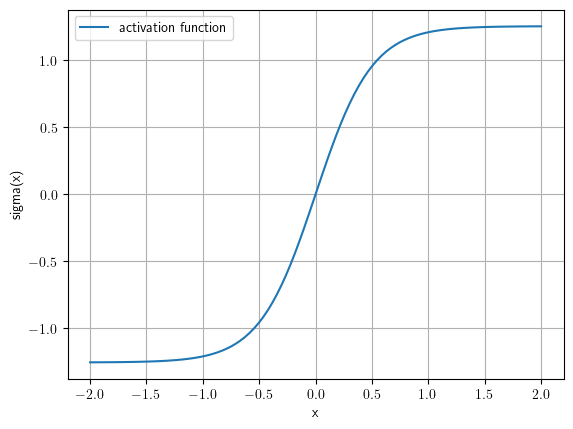

[ 0.00000000e+00  9.15241581e-01  0.00000000e+00 -7.70333160e-01
  0.00000000e+00  1.96127188e+00  0.00000000e+00 -8.38348577e+00
  0.00000000e+00  5.04972045e+01  0.00000000e+00 -3.93355039e+02
  0.00000000e+00  3.76468557e+03  0.00000000e+00 -4.27840791e+04
  0.00000000e+00  5.63449142e+05  0.00000000e+00 -8.44293231e+06
  0.00000000e+00  1.41906748e+08  0.00000000e+00 -2.64496885e+09]
0.9999999999999999
0.9992916877381335


In [8]:
# choose the activation function among the activations below
# the cell computes the first num_coeff Hermite coefficients and defines the function g()

analytical = False
activation = 'Tanh unitary'
num_coeff = 23

if (activation == 'ReLU' or activation == 'ReLU unitary'):
  analytic = True
else:
  analytic = False


if (analytic == True):
 if (activation == 'ReLU'):

      def sigma(x):
        return np.heaviside(x,1)*x

      def g_1(x):
        return -1/(2*np.pi) + x/4 + np.sqrt(1-x**2)/(2*np.pi) + x*np.arctan(x/np.sqrt(1-x**2))/(2*np.pi)

      def g_1_prime(x):
        return (np.arctan(x/np.sqrt(1-x**2)))/(2*np.pi) + 1/4

      def g_3(x):
        return -1/(2*np.pi) - x**2/(4*np.pi) + np.sqrt(1-x**2)/(2*np.pi) + x*np.arctan(x/np.sqrt(1-x**2))/(2*np.pi)

      def g_3_prime(x):
        return (np.arctan(x/np.sqrt(1-x**2))-x)/(2*np.pi)

      coefficients = hermite_coefficients(lambda x: sigma(x), num_coeff, -10, 10)

 if (activation == 'ReLU unitary'):

      var, error = scipy.integrate.quad(lambda x: (np.heaviside(x,1)*x - 1/np.sqrt(2*np.pi))**2 *np.exp(-x**2/2)/(np.sqrt(2*np.pi)), -10, 10)
      #print(var)

      def sigma(x):
        return (np.heaviside(x,1)*x - 1/np.sqrt(2*np.pi))/np.sqrt(var)

      def g_1(x):
        return (-1/(2*np.pi) + x/4 + np.sqrt(1-x**2)/(2*np.pi) + x*np.arctan(x/np.sqrt(1-x**2))/(2*np.pi))/var

      def g_1_prime(x):
        return ((np.arctan(x/np.sqrt(1-x**2)))/(2*np.pi) + 1/4)/var

      def g_3(x):
        return (-1/(2*np.pi) - x**2/(4*np.pi) + np.sqrt(1-x**2)/(2*np.pi) + x*np.arctan(x/np.sqrt(1-x**2))/(2*np.pi))/var

      def g_3_prime(x):
        return ((np.arctan(x/np.sqrt(1-x**2))-x)/(2*np.pi))/var

      coefficients = hermite_coefficients(lambda x: sigma(x), num_coeff, -10, 10)

else:

  if (activation == 'ReLU unitary coeff'):

      var, error = scipy.integrate.quad(lambda x: (np.heaviside(x,1)*x - 1/np.sqrt(2*np.pi))**2 *np.exp(-x**2/2)/(np.sqrt(2*np.pi)), -10, 10)
      #print(var)

      def sigma(x):
        return (np.heaviside(x,1)*x - 1/np.sqrt(2*np.pi))/np.sqrt(var)

  elif (activation == 'Tanh'):
    def sigma(x):
        return np.tanh(2*x)

  elif (activation == 'Tanh unitary'):
    
    var, error = scipy.integrate.quad(lambda x: (np.tanh(2*x))**2 *np.exp(-x**2/2)/(np.sqrt(2*np.pi)), -10, 10)

    def sigma(x):
        return np.tanh(2*x)/np.sqrt(var)   

  elif (activation == 'Tanh unitary no linear'):
    
    var, error = scipy.integrate.quad(lambda x: (np.tanh(2*x) - 0.729477531486114827430355944671*x)**2 *np.exp(-x**2/2)/(np.sqrt(2*np.pi)), -10, 10)

    def sigma(x):
        return (np.tanh(2*x) - 0.729477531486114827430355944671*x)/np.sqrt(var)       

  elif (activation == 'H3_tanh_wrapper_unitary'):
    def u1_np(x): return np.tanh(x)
    def u2_np(x): return np.tanh(3.0*x)   # change 3.0 to tune shape

    # compute projections under N(0,1)
    m1, _ = scipy.integrate.quad(lambda t: u1_np(t) * t * np.exp(-t**2/2) / np.sqrt(2*np.pi), -10, 10)
    m2, _ = scipy.integrate.quad(lambda t: u2_np(t) * t * np.exp(-t**2/2) / np.sqrt(2*np.pi), -10, 10)

    # coefficient to cancel H1 (linear) projection
    c = m1 / m2

    # un-normalized bounded function with H0=H1=H2=0
    def g_np(x):
      return u1_np(x) - c * u2_np(x)

    # normalize to unit variance under N(0,1)
    var_g, _ = scipy.integrate.quad(lambda t: (g_np(t)**2) * np.exp(-t**2/2) / np.sqrt(2*np.pi), -10, 10)
    var_g = float(var_g)         

    def sigma(x):
      return g_np(x) / np.sqrt(var_g) 

  elif (activation == 'LeakyReLU'):
    def sigma(x):
        return np.heaviside(x,1)*x + 0.3*np.heaviside(-x,-1)*x

  elif (activation == 'ELU'):
    def sigma(x):
        return np.heaviside(x,1)*x + np.heaviside(-x,1)*(np.exp(x) - 1)

  elif (activation == 'Sigmoid'):
    def sigma(x):
        return 1/(1+np.exp(-x))

  elif (activation == 'Quadratic'):
    def sigma(x):
        return (x**2-1)/np.sqrt(2)

  elif (activation == 'Cubic'):
    def sigma(x):
        return (x**3 - 3*x)/np.sqrt(6)

  elif (activation == 'Quadratic + Cubic'):
    def sigma(x):
        return (x**2 - 1)/np.sqrt(2) + (x**3 - 3*x)/6

  elif (activation == 'Linear + Quadratic + Cubic'):
    def sigma(x):
        return x/np.sqrt(3) + (x**2 - 1)/2 + (x**3 - 3*x)/6

  elif (activation == 'Quadratic + Quartic'):
    def sigma(x):
        return (x**2 - 1)/np.sqrt(2) + (x**4 - 6*x**2 + 3)/np.sqrt(4*3*2)

  elif (activation == 'Quartic'):
    def sigma(x):
        return (x**4 - 6*x**2 + 3)/np.sqrt(4*3*2)     

  elif (activation == 'Linear + Cubic'):
    def sigma(x):
        return (2*x + (x**3 - 3*x)/np.sqrt(6))/np.sqrt(2)     

  coefficients = hermite_coefficients(lambda x: sigma(x), num_coeff, -10, 10)

  # Create the approximation function using the computed coefficients
  def g_1(x):
    g = 0
    for i in range(1,len(coefficients)):
      g += coefficients[i]**2 * x**i / math.factorial(i)
    return g

  def g_1_prime(x):
    g = 0
    for i in range(1,len(coefficients)):
      g += coefficients[i]**2 * x**(i-1) / math.factorial(i-1)
    return g

  def g_3(x):
    g = 0
    for i in range(3,len(coefficients)):
      g += coefficients[i]**2 * x**i / math.factorial(i)
    return g

  def g_3_prime(x):
    g = 0
    for i in range(3,len(coefficients)):
      g += coefficients[i]**2 * x**(i-1) / math.factorial(i-1)
    return g

# Plot the original function
x = np.linspace(-2, 2, 100)
plt.plot(x, sigma(x), label='activation function')

plt.xlabel('x')
plt.ylabel('sigma(x)')
plt.legend()
plt.grid(True)
plt.show()

print(coefficients)
#print(f"{coefficients[1]:.30f}")
var_activ, error_activ = scipy.integrate.quad(lambda x: sigma(x)**2 * np.exp(-x**2/2)/(np.sqrt(2*np.pi)), -10, 10)
print(var_activ)
print(g_1(1))

In [245]:
# Compute the MMSE, overlaps and free entropy of the specialization phase at different values of alpha
num_v = 400  # Number of states
mult_sigma = 5  # Number of sigmas to consider
#v_ones, P_v_ones = get_states_and_probs(num_v)
s2_gauss, P_s2_gauss = get_discrete_gaussian_on_grid(num_v,0,1,mult_sigma)
#s2_gauss = [-1,1]
#P_s2_gauss = [1/2,1/2]
#s2_gauss = [-3/np.sqrt(5),-1/np.sqrt(5),1/np.sqrt(5),3/np.sqrt(5)]
#P_s2_gauss = [1/4,1/4,1/4,1/4]
v_gauss, P_v_gauss = get_discrete_gaussian_on_grid(num_v,0,1,mult_sigma)
#v_teacher = np.mean(np.sort(np.random.randn(100000, 100), axis=1), axis=0)
#v_gauss, P_v_gauss = get_states_and_probs_from_profile(v_teacher, num_bins=20)
#v_gauss = [-1,1] 
#P_v_gauss = [1/2,1/2]
s2_gauss = np.array(s2_gauss)
P_s2_gauss = np.array(P_s2_gauss)
v_gauss = np.array(v_gauss)
P_v_gauss = np.array(P_v_gauss)
q_W1_init_info = 0.99*np.ones(s2_gauss.shape[0]) # initial guess for q_W1
q_W2_init_info = 0.99*np.ones([v_gauss.shape[0],s2_gauss.shape[0]]) # initial guess for q_W2
q_W21_init_info = 0.99*np.ones(v_gauss.shape[0]) # initial guess for q_W21
q_W1_init_unfo1 = 0.99*np.ones(s2_gauss.shape[0]) # initial guess for q_W1
q_W2_init_unfo1 = 0*np.ones([v_gauss.shape[0],s2_gauss.shape[0]]) # initial guess for q_W2
q_W21_init_unfo1 = 0*np.ones(v_gauss.shape[0]) # initial guess for q_W21
q_W1_init_unfo2 = 0.0*np.ones(s2_gauss.shape[0]) # initial guess for q_W1
q_W2_init_unfo2 = 0*np.ones([v_gauss.shape[0],s2_gauss.shape[0]]) # initial guess for q_W2
q_W21_init_unfo2 = 0.99*np.ones(v_gauss.shape[0]) # initial guess for q_W21
q_W1_init_unfo3 = 0.99*np.ones(s2_gauss.shape[0]) # initial guess for q_W1
q_W2_init_unfo3 = 0.0*np.ones([v_gauss.shape[0],s2_gauss.shape[0]]) # initial guess for q_W2  
q_W21_init_unfo3 = 0.99*np.ones(v_gauss.shape[0]) # initial guess for q_W21
q_W1_init_univ = 0.0*np.ones(s2_gauss.shape[0]) # initial guess for q_W1
q_W2_init_univ = 0.0*np.ones([v_gauss.shape[0],s2_gauss.shape[0]]) # initial guess for q_W2
q_W21_init_univ = 0.0*np.ones(v_gauss.shape[0]) # initial guess for q_W21

Delta = 0.2
Gamma_1 = 0.5
Gamma_2 = 0.5
d=200


# Range of alpha
Alpha_min = 0.01
Alpha_max = 8.5

init = Alpha_min
end = Alpha_max
num = 399

MMSE_NSB_FSB_info = []
q_W_1_NSB_FSB_info = []
q_W_2_NSB_FSB_info = []
q_W_12_NSB_FSB_info = []
q_W_1_NSB_FSB_info_mean = []
q_W_2_NSB_FSB_info_mean = []
q_W_12_NSB_FSB_info_mean = []
free_entropy_NSB_FSB_info = []
MMSE_NSB_FSB_unfo1 = []
q_W_1_NSB_FSB_unfo1 = []
q_W_2_NSB_FSB_unfo1 = []
q_W_12_NSB_FSB_unfo1 = []
q_W_1_NSB_FSB_unfo1_mean = []
q_W_2_NSB_FSB_unfo1_mean = []
q_W_12_NSB_FSB_unfo1_mean = []
free_entropy_NSB_FSB_unfo1 = []
MMSE_NSB_FSB_unfo2 = []
q_W_1_NSB_FSB_unfo2 = []
q_W_2_NSB_FSB_unfo2 = []
q_W_12_NSB_FSB_unfo2 = [] 
q_W_1_NSB_FSB_unfo2_mean = []
q_W_2_NSB_FSB_unfo2_mean = []
q_W_12_NSB_FSB_unfo2_mean = []
free_entropy_NSB_FSB_unfo2 = []
MMSE_NSB_FSB_unfo3 = []
q_W_1_NSB_FSB_unfo3 = []
q_W_2_NSB_FSB_unfo3 = []
q_W_12_NSB_FSB_unfo3 = [] 
q_W_1_NSB_FSB_unfo3_mean = []
q_W_2_NSB_FSB_unfo3_mean = []
q_W_12_NSB_FSB_unfo3_mean = []
free_entropy_NSB_FSB_unfo3 = []
q_W_1_NSB_FSB_univ = []
q_W_2_NSB_FSB_univ = []
q_W_12_NSB_FSB_univ = [] 
MMSE_NSB_FSB_univ = []
q_W_1_NSB_FSB_univ_mean = []
q_W_2_NSB_FSB_univ_mean = []
q_W_12_NSB_FSB_univ_mean = []
free_entropy_NSB_FSB_univ = []


for Alpha in np.linspace(init, end, num=num):
  print('----------------------------------------------------------------')
  print("alpha =",Alpha)
  MMSE_NSB_FSB_new,q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new=mmse_qW_NSB_FSB_fast(
    q_W1_init_info,q_W2_init_info,q_W21_init_info,
    g_1, g_1_prime, g_3, g_3_prime,
    v_gauss, P_v_gauss, s2_gauss, P_s2_gauss,
    d, coefficients, Alpha, Gamma_1, Gamma_2, Delta,
    max_iter=1000, tol=1e-6, damp=0.5,
    opt='gauss')
  MMSE_NSB_FSB_info.append(MMSE_NSB_FSB_new)
  q_W_1_NSB_FSB_info.append(q_W_1_NSB_FSB_new)
  q_W_2_NSB_FSB_info.append(q_W_2_NSB_FSB_new)
  q_W_12_NSB_FSB_info.append(q_W_12_NSB_FSB_new)
  q_W_1_NSB_FSB_info_mean.append(EE_s(q_W_1_NSB_FSB_new,P_s2_gauss))
  q_W_2_NSB_FSB_info_mean.append(EE_s(EE_FSB(q_W_2_NSB_FSB_new,1,P_s2_gauss),P_v_gauss))
  q_W_12_NSB_FSB_info_mean.append(EE_s(q_W_12_NSB_FSB_new,P_v_gauss))
  free_entropy_NSB_FSB_info.append(free_entropy_NSB_FSB(
    q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new,
    g_1, g_1_prime, g_3, g_3_prime,
    v_gauss, P_v_gauss, s2_gauss, P_s2_gauss,
    d, coefficients, Alpha, Gamma_1, Gamma_2, Delta,
    max_iter=1000, tol=1e-6, damp=0.5,
    opt='gauss'))
  print('----------------------------------------------------------------')
  MMSE_NSB_FSB_new,q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new=mmse_qW_NSB_FSB_fast(
    q_W1_init_unfo1,q_W2_init_unfo1,q_W21_init_unfo1,
    g_1, g_1_prime, g_3, g_3_prime,
    v_gauss, P_v_gauss, s2_gauss, P_s2_gauss,
    d, coefficients, Alpha, Gamma_1, Gamma_2, Delta,
    max_iter=1000, tol=1e-6, damp=0.5,
    opt='gauss')
  MMSE_NSB_FSB_unfo1.append(MMSE_NSB_FSB_new)
  q_W_1_NSB_FSB_unfo1.append(q_W_1_NSB_FSB_new)
  q_W_2_NSB_FSB_unfo1.append(q_W_2_NSB_FSB_new)
  q_W_12_NSB_FSB_unfo1.append(q_W_12_NSB_FSB_new)
  q_W_1_NSB_FSB_unfo1_mean.append(EE_s(q_W_1_NSB_FSB_new,P_s2_gauss))
  q_W_2_NSB_FSB_unfo1_mean.append(EE_s(EE_FSB(q_W_2_NSB_FSB_new,1,P_s2_gauss),P_v_gauss))
  q_W_12_NSB_FSB_unfo1_mean.append(EE_s(q_W_12_NSB_FSB_new,P_v_gauss))
  free_entropy_NSB_FSB_unfo1.append(free_entropy_NSB_FSB(
    q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new,
    g_1, g_1_prime, g_3, g_3_prime,
    v_gauss, P_v_gauss, s2_gauss, P_s2_gauss,
    d, coefficients, Alpha, Gamma_1, Gamma_2, Delta,
    max_iter=1000, tol=1e-6, damp=0.5,
    opt='gauss'))
  print('----------------------------------------------------------------')
  MMSE_NSB_FSB_new,q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new=mmse_qW_NSB_FSB_fast(
    q_W1_init_unfo2,q_W2_init_unfo2,q_W21_init_unfo2,
    g_1, g_1_prime, g_3, g_3_prime,
    v_gauss, P_v_gauss, s2_gauss, P_s2_gauss,
    d, coefficients, Alpha, Gamma_1, Gamma_2, Delta,
    max_iter=1000, tol=1e-6, damp=0.5,
    opt='gauss')
  MMSE_NSB_FSB_unfo2.append(MMSE_NSB_FSB_new)
  q_W_1_NSB_FSB_unfo2.append(q_W_1_NSB_FSB_new)
  q_W_2_NSB_FSB_unfo2.append(q_W_2_NSB_FSB_new)
  q_W_12_NSB_FSB_unfo2.append(q_W_12_NSB_FSB_new)
  q_W_1_NSB_FSB_unfo2_mean.append(EE_s(q_W_1_NSB_FSB_new,P_s2_gauss))
  q_W_2_NSB_FSB_unfo2_mean.append(EE_s(EE_FSB(q_W_2_NSB_FSB_new,1,P_s2_gauss),P_v_gauss))
  q_W_12_NSB_FSB_unfo2_mean.append(EE_s(q_W_12_NSB_FSB_new,P_v_gauss))
  free_entropy_NSB_FSB_unfo2.append(free_entropy_NSB_FSB(
    q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new,
    g_1, g_1_prime, g_3, g_3_prime,
    v_gauss, P_v_gauss, s2_gauss, P_s2_gauss,
    d, coefficients, Alpha, Gamma_1, Gamma_2, Delta,
    max_iter=1000, tol=1e-6, damp=0.5,
    opt='gauss'))
  print('----------------------------------------------------------------')
  MMSE_NSB_FSB_new,q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new=mmse_qW_NSB_FSB_fast(
    q_W1_init_unfo3,q_W2_init_unfo3,q_W21_init_unfo3,
    g_1, g_1_prime, g_3, g_3_prime,
    v_gauss, P_v_gauss, s2_gauss, P_s2_gauss,
    d, coefficients, Alpha, Gamma_1, Gamma_2, Delta,
    max_iter=1000, tol=1e-6, damp=0.5,
    opt='gauss')
  MMSE_NSB_FSB_unfo3.append(MMSE_NSB_FSB_new)
  q_W_1_NSB_FSB_unfo3.append(q_W_1_NSB_FSB_new)
  q_W_2_NSB_FSB_unfo3.append(q_W_2_NSB_FSB_new)
  q_W_12_NSB_FSB_unfo3.append(q_W_12_NSB_FSB_new)
  q_W_1_NSB_FSB_unfo3_mean.append(EE_s(q_W_1_NSB_FSB_new,P_s2_gauss))
  q_W_2_NSB_FSB_unfo3_mean.append(EE_s(EE_FSB(q_W_2_NSB_FSB_new,1,P_s2_gauss),P_v_gauss))
  q_W_12_NSB_FSB_unfo3_mean.append(EE_s(q_W_12_NSB_FSB_new,P_v_gauss))
  free_entropy_NSB_FSB_unfo3.append(free_entropy_NSB_FSB(
    q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new,
    g_1, g_1_prime, g_3, g_3_prime,
    v_gauss, P_v_gauss, s2_gauss, P_s2_gauss,
    d, coefficients, Alpha, Gamma_1, Gamma_2, Delta,
    max_iter=1000, tol=1e-6, damp=0.5,
    opt='gauss'))
  print('----------------------------------------------------------------')
  MMSE_NSB_FSB_new,q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new=mmse_qW_NSB_FSB_fast(
    q_W1_init_univ,q_W2_init_univ,q_W21_init_univ,
    g_1, g_1_prime, g_3, g_3_prime,
    v_gauss, P_v_gauss, s2_gauss, P_s2_gauss,
    d, coefficients, Alpha, Gamma_1, Gamma_2, Delta,
    max_iter=1000, tol=1e-6, damp=0.5,
    opt='gauss')
  MMSE_NSB_FSB_univ.append(MMSE_NSB_FSB_new)
  q_W_1_NSB_FSB_univ.append(q_W_1_NSB_FSB_new)
  q_W_2_NSB_FSB_univ.append(q_W_2_NSB_FSB_new)
  q_W_12_NSB_FSB_univ.append(q_W_12_NSB_FSB_new)
  q_W_1_NSB_FSB_univ_mean.append(EE_s(q_W_1_NSB_FSB_new,P_s2_gauss))
  q_W_2_NSB_FSB_univ_mean.append(EE_s(EE_FSB(q_W_2_NSB_FSB_new,1,P_s2_gauss),P_v_gauss))
  q_W_12_NSB_FSB_univ_mean.append(EE_s(q_W_12_NSB_FSB_new,P_v_gauss))
  free_entropy_NSB_FSB_univ.append(free_entropy_NSB_FSB(
    q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new,
    g_1, g_1_prime, g_3, g_3_prime,
    v_gauss, P_v_gauss, s2_gauss, P_s2_gauss,
    d, coefficients, Alpha, Gamma_1, Gamma_2, Delta,
    max_iter=1000, tol=1e-6, damp=0.5,
    opt='gauss'))

----------------------------------------------------------------
alpha = 0.01
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
alpha = 0.03133165829145729
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
alpha = 0.05266331658291457
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
---------------------

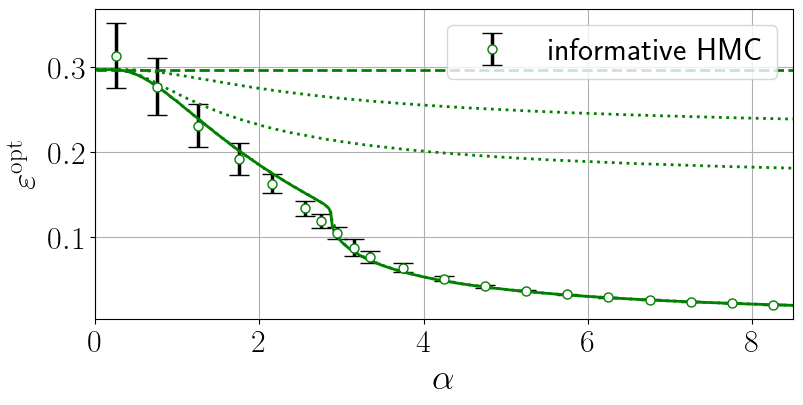

In [ ]:
import sys,pandas as pd,matplotlib.pyplot as plt,numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib

width, height = 7, 5
big, small = int(width*3.8), int(width*3.3)

fig, ax = plt.subplots(figsize=(8,4))

ax.plot(np.linspace(init, end, num=num),MMSE_NSB_FSB_info, color='green', linewidth=2.0)
ax.plot(np.linspace(init, end, num=num),MMSE_NSB_FSB_unfo1, ':', color='green', linewidth=2.0)
ax.plot(np.linspace(init, end, num=num),MMSE_NSB_FSB_unfo2, ':', color='green', linewidth=2.0)
ax.plot(np.linspace(init, end, num=num),MMSE_NSB_FSB_unfo3, ':', color='green', linewidth=2.0)
ax.plot(np.linspace(init, end, num=num),MMSE_NSB_FSB_univ, '--', color='green', linewidth=2.0)


ax.set_xlabel(r'$\alpha$', fontsize=big)
ax.set_ylabel(r'$\varepsilon^{\rm opt}$', fontsize=big)
ax.grid(True)

plt.tight_layout()
plt.legend(fontsize=small, loc='upper right')
plt.tick_params(axis='both', which='major', labelsize=small)
plt.tick_params(axis='both', which='minor', labelsize=small)
plt.xlim(0,8.5)
plt.show()      

In [149]:
# Compute the MMSE, overlaps and free entropy of the specialization phase at different values of alpha
num_v = 400  # Number of states
mult_sigma = 5  # Number of sigmas to consider
#v_ones, P_v_ones = get_states_and_probs(num_v)
s2_gauss, P_s2_gauss = get_discrete_gaussian_on_grid(num_v,0,1,mult_sigma)
#s2_gauss = [-1,1]
#P_s2_gauss = [1/2,1/2]
#s2_gauss = [-3/np.sqrt(5),-1/np.sqrt(5),1/np.sqrt(5),3/np.sqrt(5)]
#P_s2_gauss = [1/4,1/4,1/4,1/4]
v_gauss, P_v_gauss = get_discrete_gaussian_on_grid(num_v,0,1,mult_sigma)
#v_teacher = np.mean(np.sort(np.random.randn(100000, 100), axis=1), axis=0)
#v_gauss, P_v_gauss = get_states_and_probs_from_profile(v_teacher, num_bins=20)
#v_gauss = [-1,1] 
#P_v_gauss = [1/2,1/2]
s2_gauss = np.array(s2_gauss)
P_s2_gauss = np.array(P_s2_gauss)
v_gauss = np.array(v_gauss)
P_v_gauss = np.array(P_v_gauss)
q_W1_init_info = 0.99*np.ones(s2_gauss.shape[0]) # initial guess for q_W1
q_W2_init_info = 0.99*np.ones([v_gauss.shape[0],s2_gauss.shape[0]]) # initial guess for q_W2
q_W21_init_info = 0.99*np.ones(v_gauss.shape[0]) # initial guess for q_W21

q_W_1_NSB_FSB_plot = []
q_W_2_NSB_FSB_plot = []
q_W_12_NSB_FSB_plot = []
q_W_1_NSB_FS_plot = []
q_W_2_NSB_FS_plot = []
q_W_12_NSB_FS_plot = []
for a in [1.75, 2.75, 3.75]:
    print('alpha =',a)
    MMSE_NSB_xtra,q_W_1_NSB_xtra,q_W_2_NSB_xtra,q_W_12_NSB_xtra=mmse_qW_NSB_FSB_fast(q_W1_init_info,q_W2_init_info,q_W21_init_info,g_1,g_1_prime,g_3,g_3_prime,v_gauss,P_v_gauss,s2_gauss,P_s2_gauss,d,coefficients,a,Gamma_1,Gamma_2,Delta)
    q_W_1_NSB_FSB_plot.append(q_W_1_NSB_xtra)
    q_W_2_NSB_FSB_plot.append(q_W_2_NSB_xtra)
    q_W_12_NSB_FSB_plot.append(q_W_12_NSB_xtra)

alpha = 1.75
alpha = 2.75
alpha = 3.75


In [237]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Use LaTeX rendering for labels (requires LaTeX if text.usetex=True)
matplotlib.rcParams['text.usetex'] = True

width, height = 7, 5
big, small = int(width*3.3), int(width*2.7)

def _compute_edges(coords):
    """Given 1D coords of length N (cell centers), return edges length N+1."""
    coords = np.asarray(coords)
    if coords.size < 2:
        # fallback: arbitrary small edges
        return np.array([coords[0]-0.5, coords[0]+0.5])
    # midpoints between adjacent centers
    mid = 0.5 * (coords[:-1] + coords[1:])
    # first and last edges extrapolated
    first = coords[0] - (mid[0] - coords[0])
    last  = coords[-1] + (coords[-1] - mid[-1])
    edges = np.concatenate([[first], mid, [last]])
    return edges


def plot_combined(i,
                  q_W_2_NSB_FSB_plot,
                  q_W_1_NSB_FSB_plot,
                  q_W_12_NSB_FSB_plot,
                  v_gauss,
                  s2_gauss,
                  cmap='viridis',
                  figsize=(9,7),
                  main_ratio=4,    # relative size of main heatmap (height)
                  row_ratio=0.6,   # relative height for the small row heatmap under main
                  col_ratio=1.0,   # relative width for the left column
                  vmin=None,
                  vmax=None,
                  title=None,
                  fontsize=12):    # <--- new parameter to control font sizes
    """
    Combined figure:
      - main heatmap q_W_2_NSB_FSB_plot[i] with x=v_gauss and y=s2_gauss
      - a thin row heatmap under it: q_W_12_NSB_FSB_plot[i] (aligned to x)
      - a vertical column heatmap to the LEFT: q_W_1_NSB_FSB_plot[i] (aligned to y)
    """
    # --- fetch and validate data
    M = np.asarray(q_W_2_NSB_FSB_plot[i])
    v = np.asarray(v_gauss)
    s2 = np.asarray(s2_gauss)
    vec1 = np.asarray(q_W_1_NSB_FSB_plot[i])   # q_W_1 vs s2 (for the column)
    vec12 = np.asarray(q_W_12_NSB_FSB_plot[i]) # q_W_12 vs v (for the row)

    if M.ndim != 2:
        raise ValueError("q_W_2_NSB_FSB_plot[i] must be 2D.")

    nrows, ncols = M.shape

    # Align dims as in your previous function: ensure x matches cols and y matches rows (transpose if necessary)
    if v.size == ncols and s2.size == nrows:
        M_plot = M
    elif v.size == nrows and s2.size == ncols:
        M_plot = M.T
        nrows, ncols = M_plot.shape
    else:
        raise ValueError(f"Vector lengths must match matrix dimensions. Matrix shape {M.shape}, "
                         f"len(v_gauss)={v.size}, len(s2_gauss)={s2.size}.")

    # Validate 1D vectors match axes
    if vec12.size != ncols:
        raise ValueError(f"q_W_12 length {vec12.size} must match number of columns {ncols} (v axis).")
    if vec1.size != nrows:
        raise ValueError(f"q_W_1 length {vec1.size} must match number of rows {nrows} (s2 axis).")

    # compute edges
    x_edges = _compute_edges(v)
    y_edges = _compute_edges(s2)

    # compute shared color limits
    if vmin is None:
        # combine min across main, row and column
        vmin = np.nanmin([np.nanmin(M_plot), np.nanmin(vec12), np.nanmin(vec1)])
    if vmax is None:
        vmax = np.nanmax([np.nanmax(M_plot), np.nanmax(vec12), np.nanmax(vec1)])

    # --- layout with gridspec: 2 rows x 2 cols
    # Now: column on the LEFT (gs[:,0]) and main on the RIGHT (gs[:,1])
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(nrows=2, ncols=2,
                  height_ratios=[main_ratio, row_ratio],
                  width_ratios=[col_ratio, main_ratio],  # column is left now
                  hspace=0.05, wspace=0.05)

    # create left column axis first, then main and bottom row (which shares x with main)
    ax_col  = fig.add_subplot(gs[0,0])               # left column (vertical strip)
    ax_main = fig.add_subplot(gs[0,1], sharey=ax_col)  # main heatmap (to the right), share y with column
    ax_row  = fig.add_subplot(gs[1,1], sharex=ax_main) # thin row under main

    # --- main heatmap
    pcm_main = ax_main.pcolormesh(x_edges, y_edges, M_plot, shading='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax_main.set_xlabel(r'$v$', fontsize=fontsize)
    # We'll place the y-label on the left column to avoid duplication
    if title is None:
        ax_main.set_title(r'$\mathcal{Q}^*_2(v,v^{(2)})$', fontsize=fontsize)
    else:
        ax_main.set_title(title, fontsize=fontsize)

    # set limits same as you used
    ax_main.set_xlim(-2, 2)
    ax_main.set_ylim(-2, 2)

    # Hide y tick labels on the main plot so the left column shows them instead (avoids duplication)
    plt.setp(ax_main.get_yticklabels(), visible=False)
    #ax_main.yaxis.set_ticks_position('right')
    #ax_main.yaxis.set_label_position('right')
    #ax_main.tick_params(axis='y', labelsize=fontsize, which='both', direction='out')


    # keep x tick labels hidden on the main (they appear on the bottom row)
    plt.setp(ax_main.get_xticklabels(), visible=False)

    # subtle separators (optional)
    for spine in ['top','left']:
        ax_main.spines[spine].set_visible(True)

    # --- row heatmap (thin horizontal strip under main)
    row_data = vec12.reshape(1, -1)   # 1 x ncols
    y_edges_row = np.array([0.0, 1.0])
    pcm_row = ax_row.pcolormesh(x_edges, y_edges_row, row_data, shading='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    # cosmetics for row
    ax_row.set_ylabel(r'$\mathcal{Q}^*_1(v^{(2)})$', fontsize=fontsize)
    ax_row.set_yticks([])  # no numeric ticks for this dummy vertical coord
    ax_row.set_xlabel(r'$v^{(2)}$', fontsize=fontsize)
    ax_row.set_xlim(ax_main.get_xlim())
    # x-tick labels visible here and sized
    plt.setp(ax_row.get_xticklabels(), visible=True)
    ax_row.tick_params(axis='x', labelsize=fontsize)

    # --- column heatmap (vertical strip on the left): use data shape (nrows,1)
    col_data = vec1.reshape(-1, 1)    # nrows x 1
    x_edges_col = np.array([0.0, 1.0])
    pcm_col = ax_col.pcolormesh(x_edges_col, y_edges, col_data, shading='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    # cosmetics for column: show y-axis numbers here (on the left)
    ax_col.set_xticks([])          # no x ticks for the narrow column
    ax_col.set_ylim(ax_main.get_ylim())
    ax_col.set_title(r'$\mathcal{Q}^*_{2:1}(v)$', fontsize=fontsize)
    # ensure y tick labels are visible and sized on the column
    ax_col.yaxis.set_tick_params(labelsize=fontsize)
    # put the y-label (for v^(2)) on the column so it's clear
    ax_col.set_ylabel(r'$v$', fontsize=fontsize)

    # ensure main's left spine is not overlapping the column
    ax_main.spines['left'].set_visible(False)
    ax_row.spines['left'].set_visible(False)
    ax_main.set_rasterized(True)
    ax_row.set_rasterized(True)
    ax_col.set_rasterized(True)
    custom_xyticks = [-2, -1, 0, 1, 2]   # tailor to your ε‐range
    ax_col.set_yticks(custom_xyticks)
    ax_row.set_xticks(custom_xyticks)

    ax_col.set_title(r'$\mathcal{Q}^*_{2:1}(v)$', fontsize=fontsize)
    ax_col.set_ylabel(r'$v$', fontsize=fontsize)
    ax_row.set_xlabel(r'$v^{(2)}$', fontsize=fontsize)
    ax_row.set_ylabel(r'$\mathcal{Q}^*_1(v^{(2)})$', fontsize=fontsize)
    ax_main.set_title(r'$\mathcal{Q}^*_2(v,v^{(2)})$', fontsize=fontsize)

    # shared colorbar (placed to the right of the main/rightmost part of the figure)
    cbar = fig.colorbar(pcm_main, ax=[ax_main, ax_row, ax_col], orientation='vertical', fraction=0.15, pad=0.012, aspect=14)
    cbar.ax.tick_params(labelsize=fontsize)
    custom_yticks_cbar = [0.2, 0.4, 0.6, 0.8]   # tailor to your ε‐range
    cbar.ax.set_yticks(custom_yticks_cbar)

    # overall figure title (larger by 4 than fontsize)
    fig.suptitle(r'$\alpha = 1.75$', fontsize=fontsize)
    fig.set_rasterized(True)

    # adjust layout and leave room for suptitle
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig('3LNN_matrix_alpha_1.75.pdf', bbox_inches='tight')
    plt.show()
    return fig, (ax_main, ax_row, ax_col), (pcm_main, pcm_row, pcm_col)


C:\Users\rudys\AppData\Local\Temp\ipykernel_13128\1268894574.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


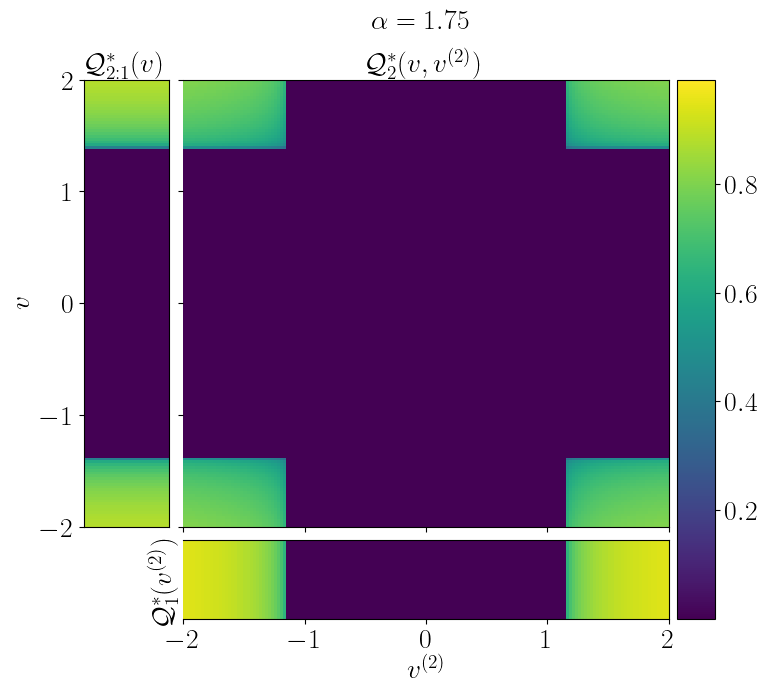

(<Figure size 900x700 with 4 Axes>,
 (<Axes: title={'center': '$\\mathcal{Q}^*_2(v,v^{(2)})$'}, xlabel='$v$'>,
  <Axes: xlabel='$v^{(2)}$', ylabel='$\\mathcal{Q}^*_1(v^{(2)})$'>,
  <Axes: title={'center': '$\\mathcal{Q}^*_{2:1}(v)$'}, ylabel='$v$'>),
 (<matplotlib.collections.QuadMesh at 0x1cbe249d720>,
  <matplotlib.collections.QuadMesh at 0x1cbec3ca080>))

In [238]:
# ------------------------
# Example usage (keeps your naming)
i = 0
plot_combined(i, q_W_2_NSB_FSB_plot, q_W_12_NSB_FSB_plot, q_W_1_NSB_FSB_plot,
               s2_gauss, v_gauss,
               cmap='viridis', figsize=(9,7), main_ratio=4, row_ratio=0.7, col_ratio=0.7,
               fontsize=20)